## PROYECTO - DETECCIÓN DE FRAUDE EN TRANSACCIONES FINANCIERAS

### 1. CARGA DE DATOS Y DESBALANCE (isfraud)

In [ ]:
import os
import pandas as pd

ruta_data = '../data/fraud_dataset.csv'

# 1.Cargar el dataset
if not os.path.exists(ruta_data):
    print(f"Error: No se encontró el archivo en {ruta_data}")
else:
    df = pd.read_csv(ruta_data)
    print("Dataset cargado correctamente\n")
    
    # 2. Ver el tamaño real
    print(f"Total de registros (filas): {df.shape[0]}")
    print(f"Total de columnas originales: {df.shape[1]}\n")
    
    # 3. Analizar el desbalance de la variable objetivo
    print("=== DISTRIBUCIÓN DE LA VARIABLE 'Fraud_Label' ===")
    conteos = df['Fraud_Label'].value_counts()
    porcentajes = df['Fraud_Label'].value_counts(normalize=True) * 100
    
    for idx in conteos.index:
        estado = "Fraude (1)" if idx == 1 else "Legítima (0)"
        print(f"  * {estado}: {conteos[idx]} registros ({porcentajes[idx]:.2f}%)")

Dataset cargado correctamente.

Total de registros (filas): 50000
Total de columnas originales: 21

=== DISTRIBUCIÓN DE LA VARIABLE 'Fraud_Label' ===
  * Legítima (0): 33933 registros (67.87%)
  * Fraude (1): 16067 registros (32.13%)


In [ ]:
# Comportamiento del Fraude (Transaction_Type)
# Mostrar columnas 
print("Columnas del dataset:", df.columns.tolist())

# Matriz de conteo: Tipo de transacción vs Fraude
tabla_tipos = pd.crosstab(df['Transaction_Type'], df['Fraud_Label'])
print("\nConteo por tipo y fraude:\n", tabla_tipos)

# Matriz de porcentaje por fila
tabla_porcentaje = pd.crosstab(df['Transaction_Type'], df['Fraud_Label'], normalize='index') * 100
print("\nPorcentaje de fraude por tipo:\n", tabla_porcentaje.round(2))

Columnas del dataset: ['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type', 'Timestamp', 'Account_Balance', 'Device_Type', 'Location', 'Merchant_Category', 'IP_Address_Flag', 'Previous_Fraudulent_Activity', 'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d', 'Card_Type', 'Card_Age', 'Transaction_Distance', 'Authentication_Method', 'Risk_Score', 'Is_Weekend', 'Fraud_Label']

Conteo por tipo y fraude:
 Fraud_Label          0     1
Transaction_Type            
ATM Withdrawal    8407  4046
Bank Transfer     8457  3995
Online            8515  4031
POS               8554  3995

Porcentaje de fraude por tipo:
 Fraud_Label           0      1
Transaction_Type              
ATM Withdrawal    67.51  32.49
Bank Transfer     67.92  32.08
Online            67.87  32.13
POS               68.16  31.84


### 2. FILTRADO Y PREPARACIÓN DE VARIABLES

In [ ]:
# seleccion de características
features = [
    'Transaction_Amount', 'Transaction_Type', 'Account_Balance', 'Device_Type', 
    'Location', 'Merchant_Category', 'IP_Address_Flag', 'Previous_Fraudulent_Activity', 
    'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d', 
    'Card_Type', 'Card_Age', 'Transaction_Distance', 'Authentication_Method', 
    'Risk_Score', 'Is_Weekend', 'Fraud_Label'
]

# Filtrado de dtaframe
df_filtered = df[features].copy()

# convertir textos categoricos a numericos (One-Hot Encoding)
df_encoded = pd.get_dummies(df_filtered, drop_first=True)

print(f"Dimensiones del dataset : {df_encoded.shape[0]} filas x {df_encoded.shape[1]} columnas.")
print("\nCaracterísticas seleccionadas y codificadas:")
print(df_encoded.columns.tolist())

Dimensiones del dataset : 50000 filas x 31 columnas.

Características seleccionadas:
['Transaction_Amount', 'Account_Balance', 'IP_Address_Flag', 'Previous_Fraudulent_Activity', 'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d', 'Card_Age', 'Transaction_Distance', 'Risk_Score', 'Is_Weekend', 'Fraud_Label', 'Transaction_Type_Bank Transfer', 'Transaction_Type_Online', 'Transaction_Type_POS', 'Device_Type_Mobile', 'Device_Type_Tablet', 'Location_Mumbai', 'Location_New York', 'Location_Sydney', 'Location_Tokyo', 'Merchant_Category_Electronics', 'Merchant_Category_Groceries', 'Merchant_Category_Restaurants', 'Merchant_Category_Travel', 'Card_Type_Discover', 'Card_Type_Mastercard', 'Card_Type_Visa', 'Authentication_Method_OTP', 'Authentication_Method_PIN', 'Authentication_Method_Password']


### ENTRENAMIENTO DEL MODELO

### Partición de datos

In [10]:
from sklearn.model_selection import train_test_split

#1. Separación características (X) y variable objetivo (y)
X = df_encoded.drop(columns=['Fraud_Label'])
y = df_encoded['Fraud_Label']

#2. Partición de datos, 80% Entrenamiento y 20% Prueba 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("=== PARTICIÓN DE DATOS ===")
print(f"Registros de Entrenamiento (X_train): {X_train.shape[0]}")
print(f"Registros de Validación/Prueba (X_test): {X_test.shape[0]}")

=== PARTICIÓN DE DATOS ===
Registros de Entrenamiento (X_train): 40000
Registros de Validación/Prueba (X_test): 10000


### Entrenamiento - árbol de decisión

=== METRICAS CLAVE DEL ÁRBOLES DE DECISIÓN ===
Exactitud Global (Accuracy): 1.0000

Reporte de Clasificación Detallado:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6787
           1       1.00      1.00      1.00      3213

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



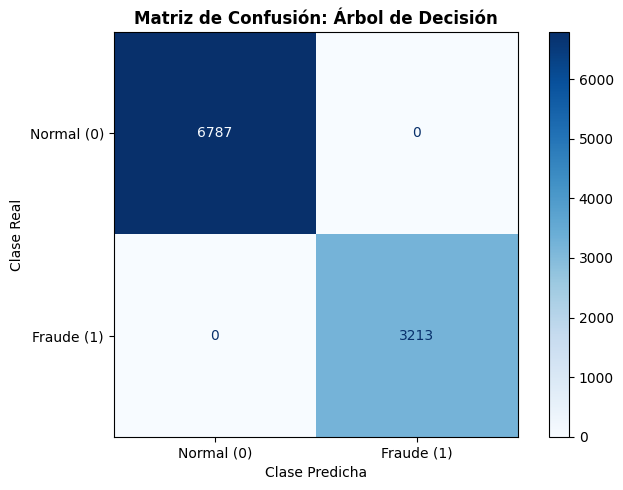

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. árbol con un límite de 5 niveles
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

# 2. Entrenar el modelo
dt_model.fit(X_train, y_train)

# 3.predicciones utilizando el conjunto de prueba
y_pred = dt_model.predict(X_test)

#resultados
print("=== METRICAS CLAVE DEL ÁRBOLES DE DECISIÓN ===")
print(f"Exactitud Global (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print("\nReporte de Clasificación Detallado:")
print(classification_report(y_test, y_pred))

# Matriz de Confusión 
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['Normal (0)', 'Fraude (1)'],
    cmap='Blues',
    ax=ax
)

plt.title('Matriz de Confusión: Árbol de Decisión', fontsize=12, fontweight='bold')
plt.xlabel('Clase Predicha', fontsize=10)
plt.ylabel('Clase Real', fontsize=10)
plt.tight_layout()
plt.show()

### Entrenamiento - Regresión logística

=== METRICAS CLAVE DE REGRESIÓN LOGÍSTICA ===
Exactitud Global (Accuracy): 0.7991

Reporte de Clasificación Detallado:
              precision    recall  f1-score   support

           0       0.84      0.87      0.86      6787
           1       0.71      0.64      0.67      3213

    accuracy                           0.80     10000
   macro avg       0.77      0.76      0.76     10000
weighted avg       0.80      0.80      0.80     10000



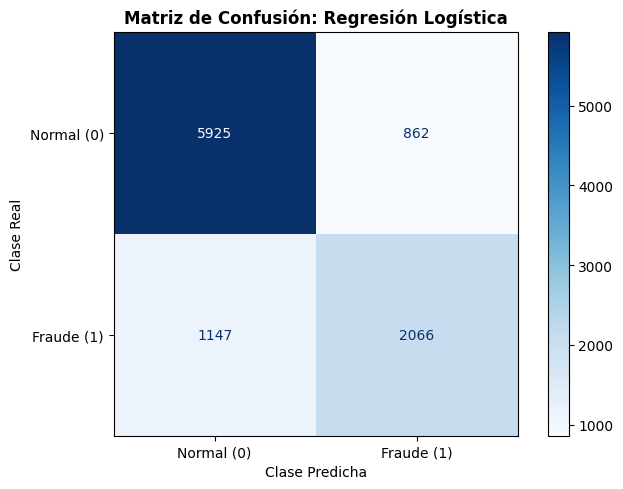

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Escalar los datos  para este modelo
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. entrenar el modelo con los datos escalados
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

# 3. predicciones
y_pred_log = log_model.predict(X_test_scaled)

print("=== METRICAS CLAVE DE REGRESIÓN LOGÍSTICA ===")
print(f"Exactitud Global (Accuracy): {accuracy_score(y_test, y_pred_log):.4f}")
print("\nReporte de Clasificación Detallado:")
print(classification_report(y_test, y_pred_log))

# Matriz de Confusión 
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log,
    display_labels=['Normal (0)', 'Fraude (1)'],
    cmap='Blues',
    ax=ax
)
plt.title('Matriz de Confusión: Regresión Logística', fontsize=12, fontweight='bold')
plt.xlabel('Clase Predicha', fontsize=10)
plt.ylabel('Clase Real', fontsize=10)
plt.tight_layout()
plt.show()

### Entrenamineto - KNN

=== METRICAS CLAVE DE K-NEAREST NEIGHBORS (KNN) ===
Exactitud Global (Accuracy): 0.7485

Reporte de Clasificación Detallado:
              precision    recall  f1-score   support

           0       0.76      0.92      0.83      6787
           1       0.69      0.39      0.50      3213

    accuracy                           0.75     10000
   macro avg       0.73      0.66      0.67     10000
weighted avg       0.74      0.75      0.73     10000



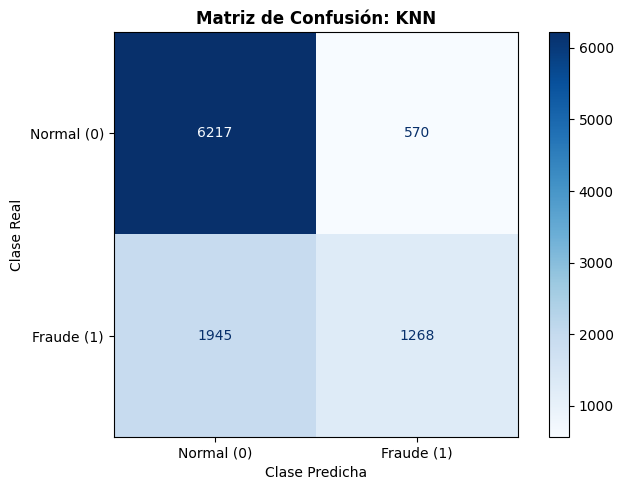

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. modelo KNN 5 vecinos por defecto
knn_model = KNeighborsClassifier(n_neighbors=5)

# 2. Entrenar el modelo con datos escalados
knn_model.fit(X_train_scaled, y_train)

# 3. predicciones con el conjunto de prueba
y_pred_knn = knn_model.predict(X_test_scaled)

print("=== METRICAS CLAVE DE K-NEAREST NEIGHBORS (KNN) ===")
print(f"Exactitud Global (Accuracy): {accuracy_score(y_test, y_pred_knn):.4f}")
print("\nReporte de Clasificación Detallado:")
print(classification_report(y_test, y_pred_knn))

# Matriz de Confusión 
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_knn,
    display_labels=['Normal (0)', 'Fraude (1)'],
    cmap='Blues',
    ax=ax
)
plt.title('Matriz de Confusión: KNN', fontsize=12, fontweight='bold')
plt.xlabel('Clase Predicha', fontsize=10)
plt.ylabel('Clase Real', fontsize=10)
plt.tight_layout()
plt.show()